In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

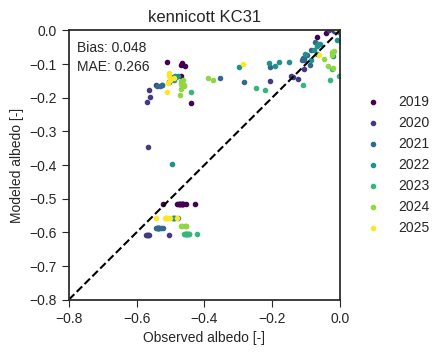

In [18]:
glacier, site = 'kennicott','KC31'
ds = xr.open_dataset(base_fp + f'ddf/{glacier+site}_2026_05_07_test_0.nc')

albedo = Albedo(glacier, site)
albedo.get_model_albedo(ds)
albedo.get_deltas()
albedo.plot_1to1()

In [ ]:
wind_factors = [1, 1.2, 1.5, 2, 2.5, 3]

fn = 'ddf/calibrate_wind/grid_{g}_{s}_windfactor{w}_0.nc'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
only = False # 'good'
snow_only = True
for glacier in site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in site_dict[glacier]:
        best = np.inf 
        for wind_factor in wind_factors:
            fn_ds = base_fp + fn.format(g=glacier, s=site, w=wind_factor)
            try:
                ds = xr.open_dataset(fn_ds)
            except:
                continue

            albedo_data = Albedo(glacier, site, use='all')
            albedo_data.get_model_albedo(ds, snow_only=snow_only)
            mb_data = MassBalance(glacier, site, use='benchmark')
            mb_data.get_model_mb(ds)

            if mb_data.dataset == 'seasonal':
                error , _= mb_data.mae(True)
            else:
                error = mb_data.mae()

            if error < best:
                best = error 
                best_ds = ds
                best_wind = wind_factor
            
            # if len(mb_data.mod) < 2:
            #     print('insufficient data')
            #     continue
            # elif mb_data.dataset == 'seasonal':
            #     me_summer, me_winter = mb_data.bias(True)
            #     if np.abs(me_summer) > 0.5 or np.abs(me_winter) > 0.5:
            #         # print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
            #         print(glacier, site, 'has biased mass balance')
            #         print('Summer mass balance bias:',me_summer)
            #         print('Winter mass balance bias:',me_winter)
            #         print('Albedo bias:',albedo_data.bias())
            #         print()
            #         if only == 'bad':
            #             for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            #                 all_mod_albedo.append(mod)
            #                 all_meas_albedo.append(meas)
            #                 all_time_albedo.append(t)
            #         # mb_data.plot_mb()
            #     else:
            #         print(glacier, site, 'is good')
            #         if only == 'good':
            #             for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            #                 all_mod_albedo.append(mod)
            #                 all_meas_albedo.append(meas)
            #                 all_time_albedo.append(t)
                    
            # else:
            #     if np.abs(mb_data.mae()) > 0.5:
            #         # print(ds.attrs['glacier'], ds.attrs['site'],'has biased mass balance using kp=',ds.attrs['kp'])
            #         print('Annual mass balance bias:',mb_data.mae())
            #         print('Albedo bias:',albedo_data.bias())
            #         print()
            #         # mb_data.plot_mb()
            #         if only == 'bad':
            #             for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            #                 all_mod_albedo.append(mod)
            #                 all_meas_albedo.append(meas)
            #                 all_time_albedo.append(t)
            #     else:
            #         print(glacier, site, 'is good')
            #         if only == 'good':
            #             for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            #                 all_mod_albedo.append(mod)
            #                 all_meas_albedo.append(meas)
            #                 all_time_albedo.append(t)
                    
            # if not only:
            #     for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            #         all_mod_albedo.append(mod)
            #         all_meas_albedo.append(meas)
            #         all_time_albedo.append(t)

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(best_ds, snow_only=snow_only)
        mb_data = MassBalance(glacier, site, use='benchmark')
        mb_data.get_model_mb(best_ds)
        print(glacier, site, 'wind factor of',best_wind)
        
        if mb_data.dataset == 'seasonal':
            mae_summer, mae_winter = mb_data.mae(True)
            print('Summer mass balance MAE:',mae_summer)
            print('Winter mass balance MAE:',mae_winter)

            me_summer, me_winter = mb_data.bias(True)
            print('Summer mass balance bias:',me_summer)
            print('Winter mass balance bias:',me_winter)
        else:
            print('Annual mass balance MAE:',mb_data.mae())
            print('Annual mass balance bias', mb_data.bias())

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

        # plot
        # mb_data.plot_mb()
        # albedo_data.plot_timeseries()
        # albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)


wolverine N wind factor of 1.5
Summer mass balance MAE: 0.5951795408834383
Winter mass balance MAE: 0.2768491478914976
Summer mass balance bias: 0.4321935102243996
Winter mass balance bias: 0.15006909169150395
wolverine B wind factor of 1.5
Summer mass balance MAE: 0.8383212286173467
Winter mass balance MAE: 0.36319386054551006
Summer mass balance bias: 0.8001084659680618
Winter mass balance bias: 0.28282061131239616
wolverine EC wind factor of 2
Summer mass balance MAE: 0.40853512364378153
Winter mass balance MAE: 0.4825611639950434
Summer mass balance bias: 0.3352966966158695
Winter mass balance bias: 0.4340617874374891
kahiltna K53 wind factor of 1.5
Summer mass balance MAE: 0.38330357438720714
Winter mass balance MAE: 0.377350433202788
Summer mass balance bias: -0.04771303740675005
Winter mass balance bias: 0.31325969794374825
kahiltna K17b wind factor of 1
Summer mass balance MAE: 0.7047619047619047
Winter mass balance MAE: 0.8175000000000001
Summer mass balance bias: 0.6980952380

In [6]:
fn = 'ddf/{g}{s}_2026_05_07_test_0.nc'

# glaciers = ['gulkana','kennicott', 'wolverine', 'lemon_creek', 'kahiltna']
# sites = [['B','D'], ['GTL','GTH'], ['N','EC'], ['B','D'], ['K53','K17b']]

# for (g, (site1, site2)) in zip(glaciers, sites):
#     years = np.arange(2019, 2025)
#     fig, axes = plt.subplots(2, 3, figsize=(8, 6), gridspec_kw={'hspace':0.3, 'wspace': 0.3})
#     axes = axes.flatten()
#     for yr, ax in zip(years, axes):
#         ds1 = xr.open_dataset(base_fp + fn.format(g=g, s=site1))
#         ds2 = xr.open_dataset(base_fp + fn.format(g=g, s=site2))

#         ds1 = ds1.sel(time=slice(f'{yr}-04-01',f'{yr}-08-20'))
#         ds2 = ds2.sel(time=slice(f'{yr}-04-01',f'{yr}-08-20'))

#         ax.plot(ds1.time, ds1.albedo, label=site1)
#         ax.plot(ds2.time, ds2.albedo, label=site2)

#         albedo1 = Albedo(g, site1)
#         albedo2 = Albedo(g, site2)
#         ax.scatter(albedo1.time, albedo1.data, label='Satellite')
#         ax.scatter(albedo2.time, albedo2.data)

#         if g == 'gulkana':
#             if yr == 2024:
#                 df = pd.read_csv('../../climate_data/AWS/Processed/gulkana2024_walbedo.csv', parse_dates=True, index_col=0)
#                 df = df.loc[pd.date_range(f'{yr}-04-20',f'{yr}-08-20')]
#                 ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             elif yr == 2025:
#                 df = pd.read_csv('../../climate_data/AWS/Processed/gulkanaB2025_albedo.csv', parse_dates=True, index_col=0)
#                 df = df.loc[df.index.hour.isin(range(13, 15))].resample('d').mean()
#                 df = df.loc[pd.date_range(f'{yr}-04-23',f'{yr}-08-20')]
#                 ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#         ax.set_xlim(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'))
#         ax.set_xticks(pd.date_range(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'), freq='2MS'))
#         ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%Y'))
#         ax.minorticks_on()
#         ax.tick_params(length=5)
#     ax.legend()
#     # lax = fig.add_axes([1, 0.3, 0.2, 0.4])
#     # lax.axis('off')
#     # lax.plot(np.nan, np.nan, label=site1)
#     # lax.plot(np.nan, np.nan, label=site2)
#     # lax.scatter(np.nan, np.nan, label='observed')
#     # lax.legend(bbox_to_anchor=(0.5,0.5), loc='center')
#     name = ' '.join(g.split('_')).capitalize()
#     fig.suptitle(name, y=0.93)
#     plt.savefig(base_fp + f'../figs/ddf/albedo_comparison_{g}.png', bbox_inches='tight')
#     plt.show()

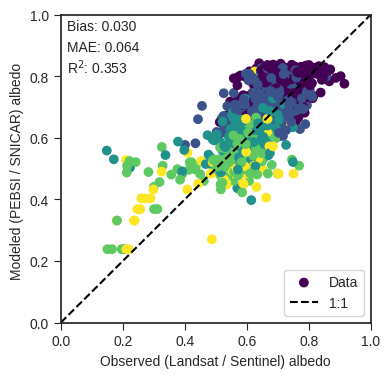

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
ax.tick_params(length=5)
# ax.set_title('Albedo modeled at Gulkana Glacier')
ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/bad_sites.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:

# albedo.plot_1to1()
# for year in range(2019, 2025):
#     albedo.plot_timeseries(years=[year])

In [43]:
glacier, site = 'taku','Taku-1'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
ds = ds.sel(time=slice('2016-07-18','2016-07-19'), layer=0).max(dim='time')
print('TAKU')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')

l = LAPs(site)
print('Measured BC', l.bc_july, 'Measured dust', l.dust_july)
print()

glacier, site = 'gulkana','D'
ds = xr.open_dataset(base_fp + fn.replace('ratios3','test').format(g=glacier, s=site))

ds = ds.sel(time=slice('2024-08-21','2024-08-22'), layer=0).max(dim='time')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')
print('Measured BC between 2.9 and 10.5', 'Measured dust between 121-262')

TAKU
PEBSI BC 12.6    PEBSI dust 33.3    PEBSI Albedo 0.570
Measured BC 6.9 Measured dust 25

PEBSI BC 5.1    PEBSI dust 0.5    PEBSI Albedo 0.706
Measured BC between 2.9 and 10.5 Measured dust between 121-262


In [ ]:
#######################################################################################